In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [6]:
def load_session(session_dir):
    session_dir = Path(session_dir)
    
    acc = pd.read_csv(session_dir / "Accelerometer.csv")
    gyr = pd.read_csv(session_dir / "Gyroscope.csv")
    lin = pd.read_csv(session_dir / "Linear Accelerometer.csv")
    
    # Standardise column names
    acc.columns = ["time", "acc_x", "acc_y", "acc_z"]
    gyr.columns = ["time", "gyr_x", "gyr_y", "gyr_z"]
    lin.columns = ["time", "lin_x", "lin_y", "lin_z"]
    
    # Merge all 3 sensors on nearest timestamp
    df = pd.merge_asof(acc.sort_values("time"),
                       gyr.sort_values("time"),
                       on="time", direction="nearest")
    df = pd.merge_asof(df,
                       lin.sort_values("time"),
                       on="time", direction="nearest")
    return df


# ── 2. SYMMETRIC TRIM TO EXACTLY 30s ─────────────────────────────────────────

def trim_to_duration(df, target_seconds=30.0):
    total = df["time"].max() - df["time"].min()
    excess = total - target_seconds
    
    if excess <= 0:
        print(f"  ⚠️  Recording is {total:.2f}s — shorter than target, skipping trim")
        return df
    
    trim_each_side = excess / 2
    new_start = df["time"].min() + trim_each_side
    new_end   = df["time"].max() - trim_each_side
    
    trimmed = df[(df["time"] >= new_start) & (df["time"] <= new_end)].copy()
    
    # Reset time to start from 0
    trimmed["time"] = trimmed["time"] - trimmed["time"].min()
    
    print(f"  Original: {total:.2f}s → trimmed {trim_each_side:.2f}s each side → {trimmed['time'].max():.2f}s")
    return trimmed


# ── 3. LOAD ALL SESSIONS (SUBJECT 1 & 2 ONLY) ────────────────────────────────

def load_all_sessions(data_dir="../data/raw/", subjects=["subject_1", "subject_2"]):
    all_sessions = []
    data_dir = Path(data_dir)
    
    for subject in subjects:
        subject_dir = data_dir / subject
        if not subject_dir.exists():
            print(f"⚠️  {subject} directory not found, skipping")
            continue
            
        for activity_dir in sorted(subject_dir.iterdir()):
            if not activity_dir.is_dir():
                continue
                
            for session_dir in sorted(activity_dir.iterdir()):
                if not session_dir.is_dir():
                    continue
                
                print(f"Loading {subject}/{activity_dir.name}/{session_dir.name}")
                
                try:
                    df = load_session(session_dir)
                    df = trim_to_duration(df, target_seconds=30.0)
                    
                    # Attach labels
                    df["subject"]  = subject
                    df["activity"] = activity_dir.name
                    df["session"]  = session_dir.name
                    
                    all_sessions.append(df)
                    
                except FileNotFoundError as e:
                    print(f"  ❌ Missing file in {session_dir.name}: {e}")
                except Exception as e:
                    print(f"  ❌ Error in {session_dir.name}: {e}")
    
    full_df = pd.concat(all_sessions, ignore_index=True)
    print(f"\n✅ Loaded {len(all_sessions)} sessions — {len(full_df)} total rows")
    return full_df

In [7]:
df = load_all_sessions()

# Sanity checks
print("\n── Sanity Checks ──────────────────────────────")
print("Sessions loaded:", df.groupby(["subject", "activity", "session"]).ngroups)
print("\nActivity counts:\n", df["activity"].value_counts())
print("\nDuration per session (should all be ~30s):")
durations = df.groupby(["subject", "activity", "session"])["time"].max()
print(durations.describe().round(2))
print("\nMissing values:\n", df.isnull().sum())
print("\nSample:\n", df.head())

Loading subject_1/cooking/session_01
  Original: 39.16s → trimmed 4.58s each side → 29.99s
Loading subject_1/cooking/session_02
  Original: 40.05s → trimmed 5.03s each side → 30.00s
Loading subject_1/cooking/session_03
  Original: 42.43s → trimmed 6.21s each side → 29.99s
Loading subject_1/cooking/session_04
  Original: 43.88s → trimmed 6.94s each side → 29.99s
Loading subject_1/cooking/session_05
  Original: 42.45s → trimmed 6.23s each side → 29.99s
Loading subject_1/cooking/session_06
  Original: 41.70s → trimmed 5.85s each side → 29.99s
Loading subject_1/cooking/session_07
  Original: 43.78s → trimmed 6.89s each side → 29.99s
Loading subject_1/cooking/session_08
  Original: 43.02s → trimmed 6.51s each side → 30.00s
Loading subject_1/exercising/session_01
  Original: 41.29s → trimmed 5.64s each side → 30.00s
Loading subject_1/exercising/session_02
  Original: 39.37s → trimmed 4.69s each side → 29.99s
Loading subject_1/exercising/session_03
  Original: 38.02s → trimmed 4.01s each side

In [4]:
#df.to_parquet("../outputs/features/combined_raw.parquet", index=False)

# Load it back later with just:
df = pd.read_parquet("../outputs/features/combined_raw.parquet")

In [5]:
df.describe()

,time,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,lin_x,lin_y,lin_z
count,240804.000000,240804.000000,240804.000000,240804.000000,240804.000000,240804.000000,240804.000000,240804.000000,240804.000000,240804.000000
mean,14.995586,-4.412687,-2.692591,3.240774,0.000095,0.002717,-0.009275,-0.020241,-0.254812,-0.043925
std,8.660599,5.305185,4.673990,3.607793,0.605953,0.728110,0.718696,1.307712,0.910362,0.873632
min,0.000000,-20.617825,-18.429526,-12.674743,-3.741375,-8.768705,-4.131027,-13.777359,-10.666996,-10.313959
25%,7.495633,-7.950267,-6.489605,0.973725,-0.110568,-0.124383,-0.125295,-0.253637,-0.448634,-0.207772
50%,14.997112,-6.266419,-2.349664,2.761008,-0.000382,0.000384,-0.000424,-0.041122,-0.016607,0.000329
75%,22.497782,-3.355946,-0.800685,6.500569,0.081422,0.140948,0.077004,0.127626,0.045106,0.138971
max,29.998860,25.619524,9.573342,17.192947,3.704149,7.390010,3.312046,19.699358,6.900128,10.597314


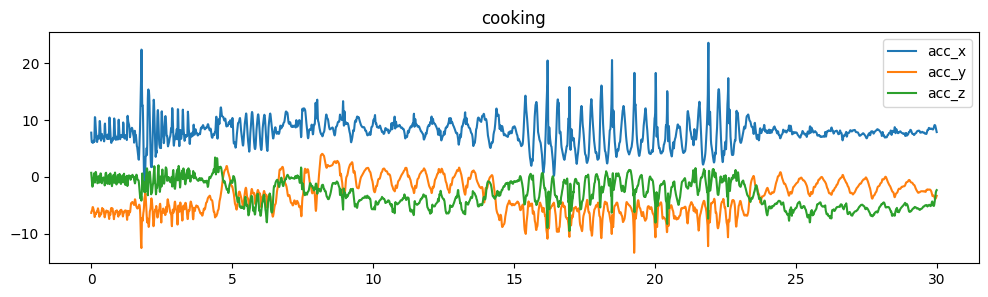

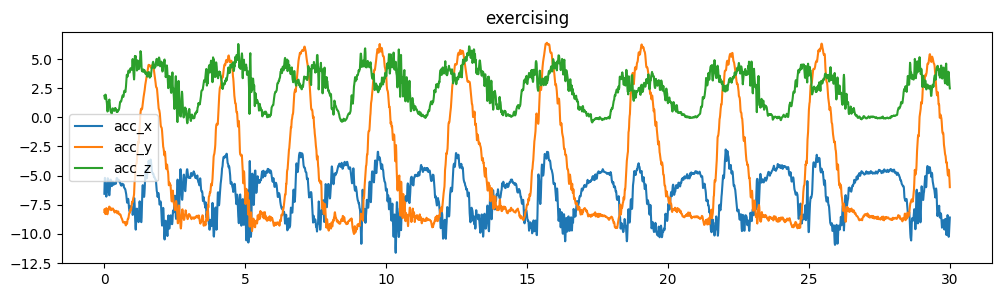

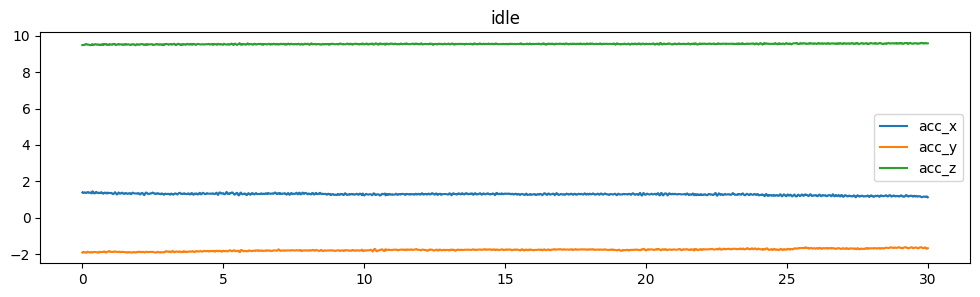

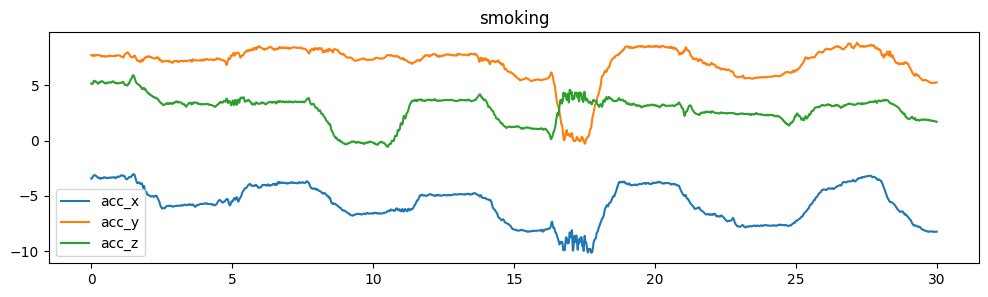

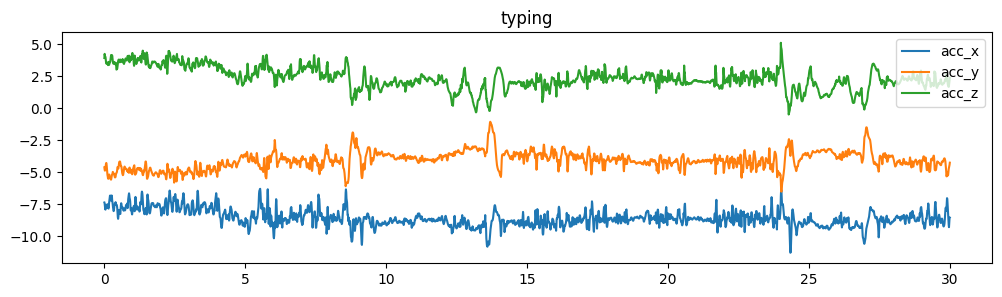

In [6]:
import matplotlib.pyplot as plt

# Plot raw signal for one session of each activity
for activity in df["activity"].unique():
    sample = df[(df["activity"] == activity) & 
                (df["session"] == "session_01") & 
                (df["subject"] == "subject_1")]
    
    plt.figure(figsize=(12, 3))
    plt.plot(sample["time"], sample["acc_x"], label="acc_x")
    plt.plot(sample["time"], sample["acc_y"], label="acc_y")
    plt.plot(sample["time"], sample["acc_z"], label="acc_z")
    plt.title(activity)
    plt.legend()
    plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal
from scipy.fft import rfft, rfftfreq

# ── SETUP ─────────────────────────────────────────────────────────────────────

ACTIVITIES  = ["smoking", "typing", "idle", "cooking", "exercising"]
PALETTE     = dict(zip(ACTIVITIES, ["#e63946","#457b9d","#6a994e","#e9c46a","#f4a261"]))
SENSOR_COLS = ["acc_x","acc_y","acc_z","gyr_x","gyr_y","gyr_z","lin_x","lin_y","lin_z"]

# Assumes df is already loaded, merged, and trimmed

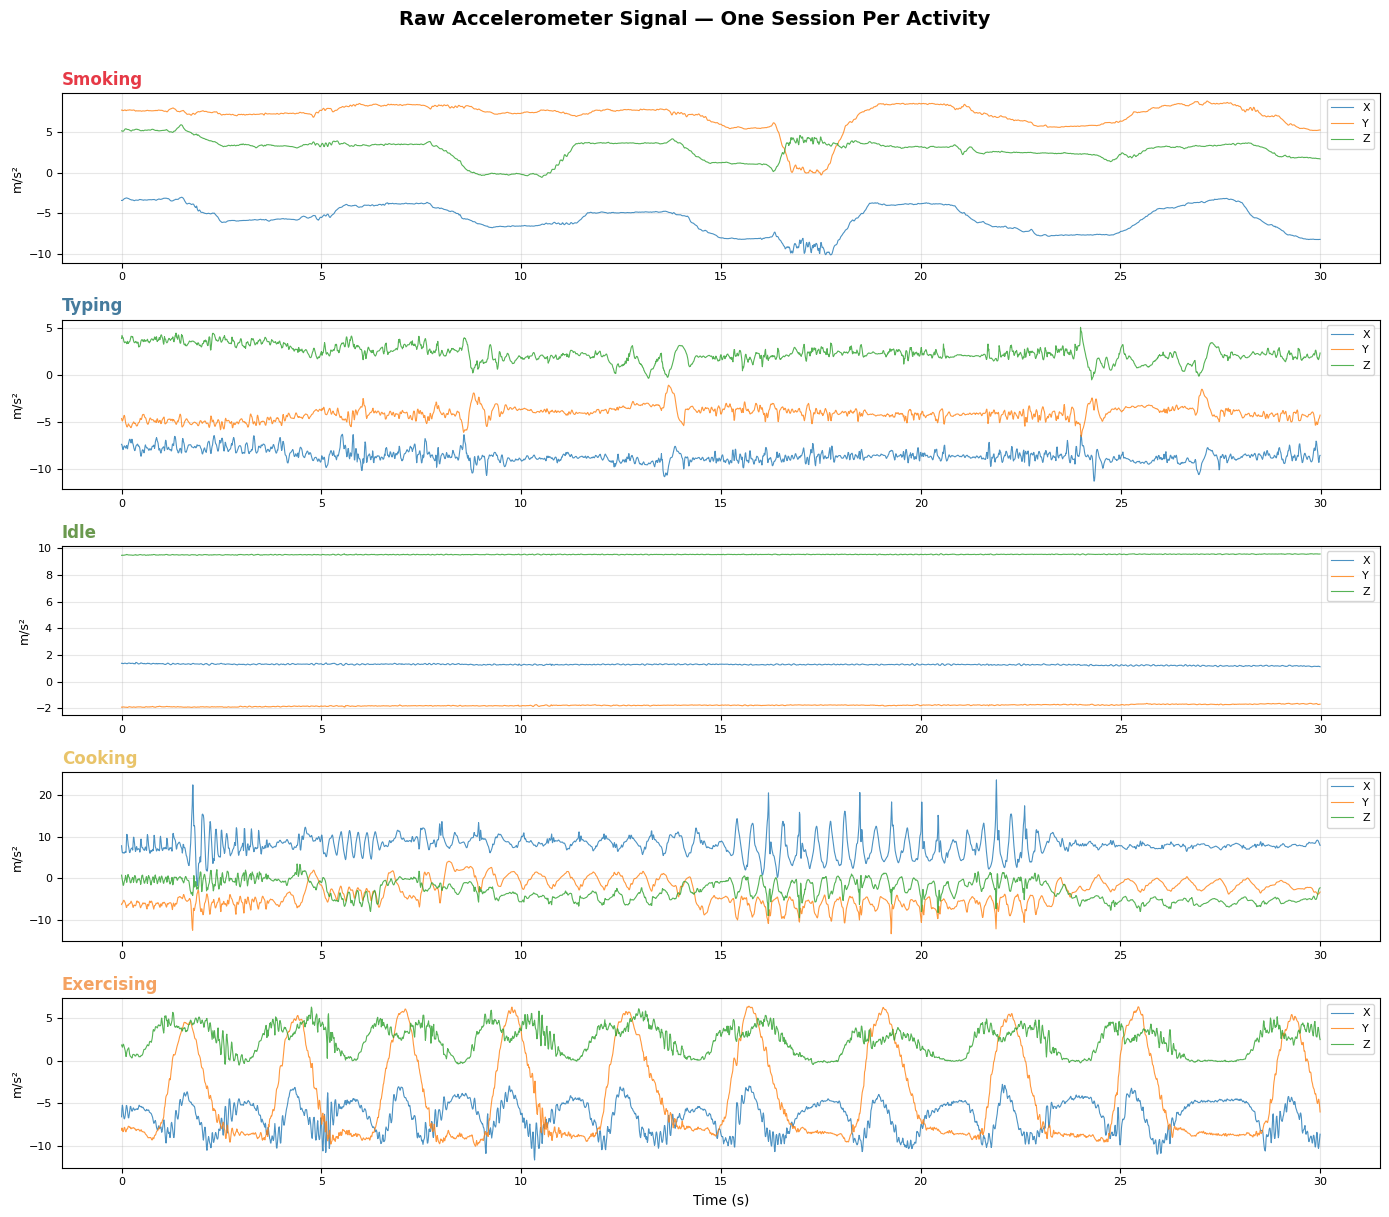

In [35]:
# ── RAW TIME SERIES ───────────────────────────────────────────────────────────
# Shows what each activity actually looks like on the accelerometer
# The most important sanity check — you want these to look visually distinct

fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 12), sharex=False)
fig.suptitle("Raw Accelerometer Signal — One Session Per Activity", 
             fontsize=14, fontweight="bold", y=1.01)

for ax, activity in zip(axes, ACTIVITIES):
    sample = df[
        (df["activity"] == activity) &
        (df["session"]  == "session_01") &
        (df["subject"]  == "subject_1")
    ]
    ax.plot(sample["time"], sample["acc_x"], label="X", alpha=0.8, linewidth=0.8)
    ax.plot(sample["time"], sample["acc_y"], label="Y", alpha=0.8, linewidth=0.8)
    ax.plot(sample["time"], sample["acc_z"], label="Z", alpha=0.8, linewidth=0.8)
    ax.set_ylabel("m/s²", fontsize=9)
    ax.set_title(activity.capitalize(), color=PALETTE[activity], 
                 fontweight="bold", loc="left")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("../outputs/eda/01_raw_signal.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/4214015350.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/4214015350.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,


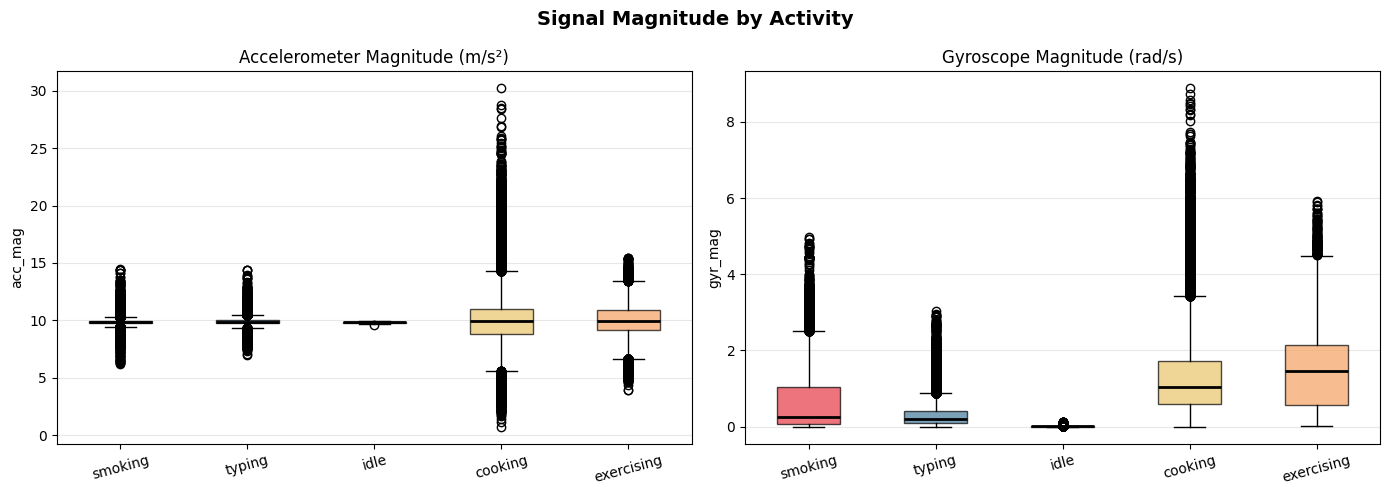

In [8]:
# ── MAGNITUDE COMPARISON ──────────────────────────────────────────────────────
# Computes resultant magnitude (sqrt(x²+y²+z²)) for acc and gyr
# Instantly shows the energy level difference between activities

df["acc_mag"] = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
df["gyr_mag"] = np.sqrt(df["gyr_x"]**2 + df["gyr_y"]**2 + df["gyr_z"]**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Signal Magnitude by Activity", fontsize=14, fontweight="bold")

for ax, col, title in zip(axes, 
                           ["acc_mag", "gyr_mag"], 
                           ["Accelerometer Magnitude (m/s²)", "Gyroscope Magnitude (rad/s)"]):
    data_to_plot = [df[df["activity"] == act][col].values for act in ACTIVITIES]
    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
                    medianprops=dict(color="black", linewidth=2))
    
    for patch, activity in zip(bp["boxes"], ACTIVITIES):
        patch.set_facecolor(PALETTE[activity])
        patch.set_alpha(0.7)
    
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/eda/02_magnitude_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# What to look for:
# exercising should have highest magnitude
# idle should be lowest
# typing should have low magnitude but high variance on Z axis

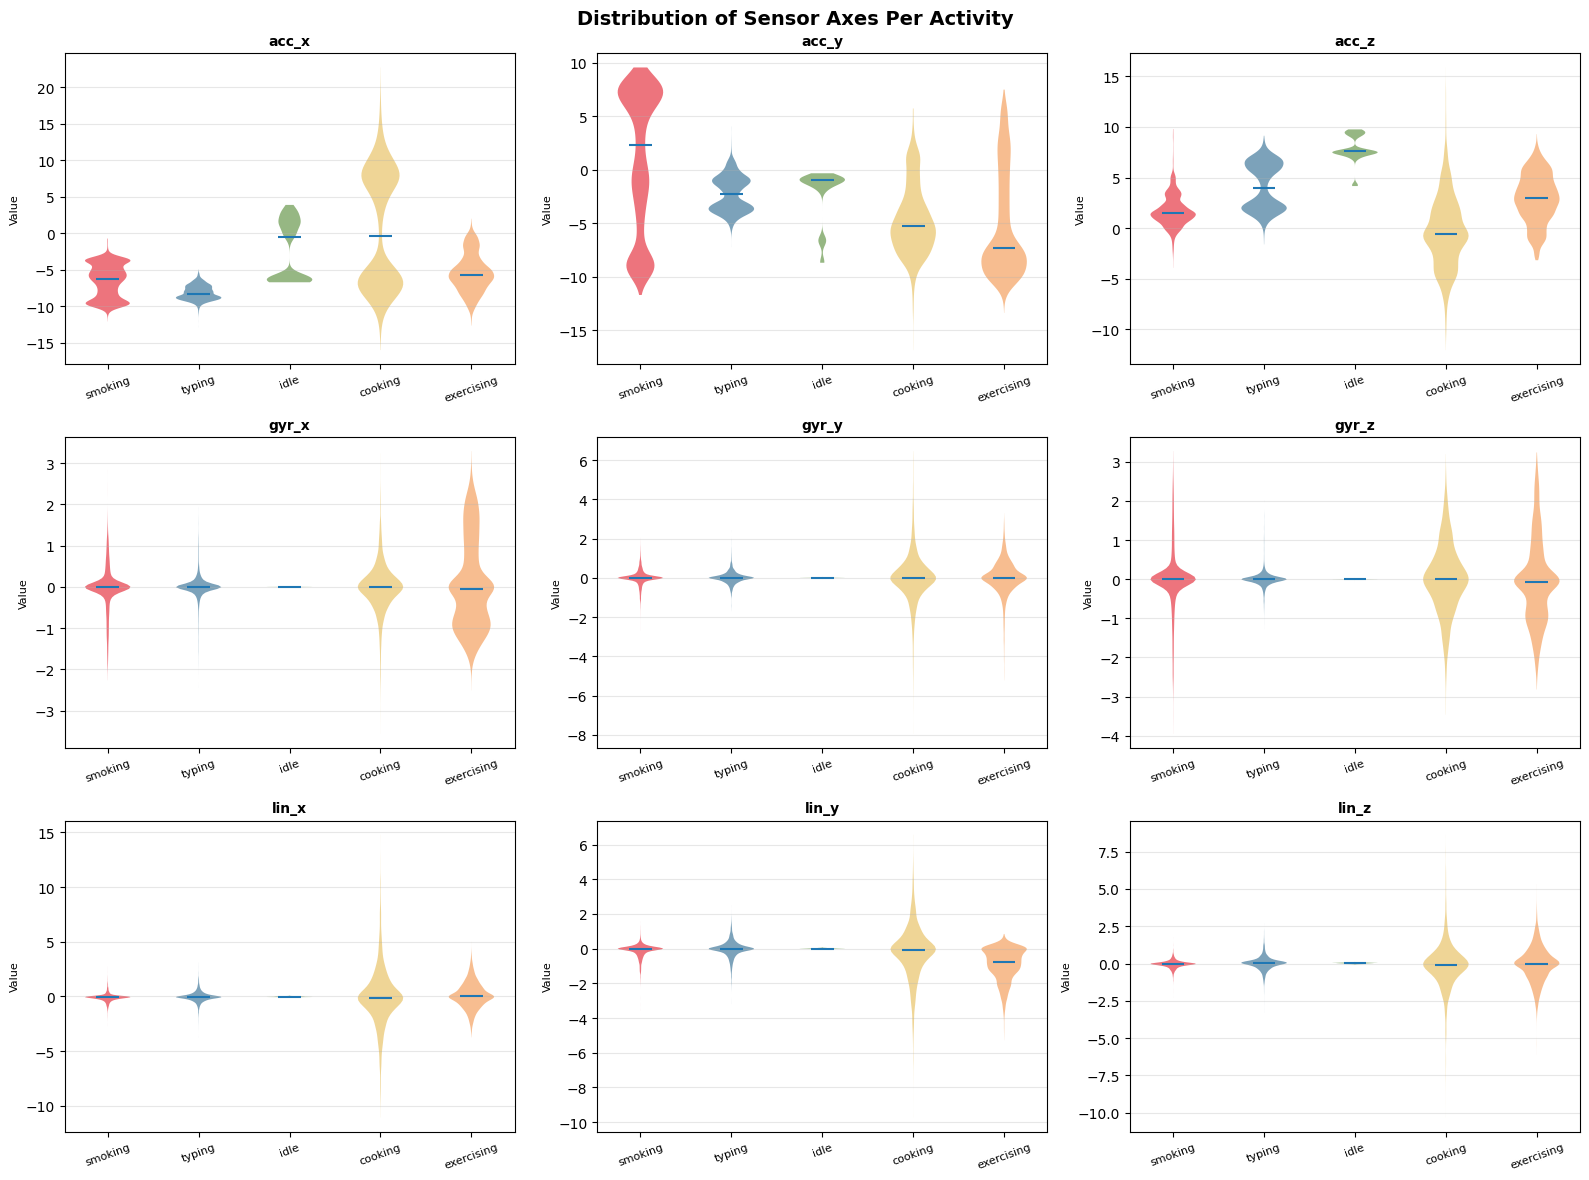

In [39]:
# ── VIOLIN PLOTS ──────────────────────────────────────────────────────────────
# More informative than boxplots — shows the full distribution shape
# Good for spotting bimodal distributions (e.g. smoking has up AND down stroke)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Distribution of Sensor Axes Per Activity", 
             fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), SENSOR_COLS):
    plot_data = []
    labels    = []
    for activity in ACTIVITIES:
        vals = df[df["activity"] == activity][col].values
        # Subsample to keep plotting fast
        plot_data.append(vals[::10])
        labels.append(activity)
    
    parts = ax.violinplot(plot_data, showmedians=True, showextrema=False)
    
    for i, (pc, activity) in enumerate(zip(parts["bodies"], ACTIVITIES)):
        pc.set_facecolor(PALETTE[activity])
        pc.set_alpha(0.7)
    
    ax.set_xticks(range(1, len(ACTIVITIES)+1))
    ax.set_xticklabels(ACTIVITIES, rotation=20, fontsize=8)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_ylabel("Value", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/eda/03_violin_plots.png", dpi=150, bbox_inches="tight")
plt.show()

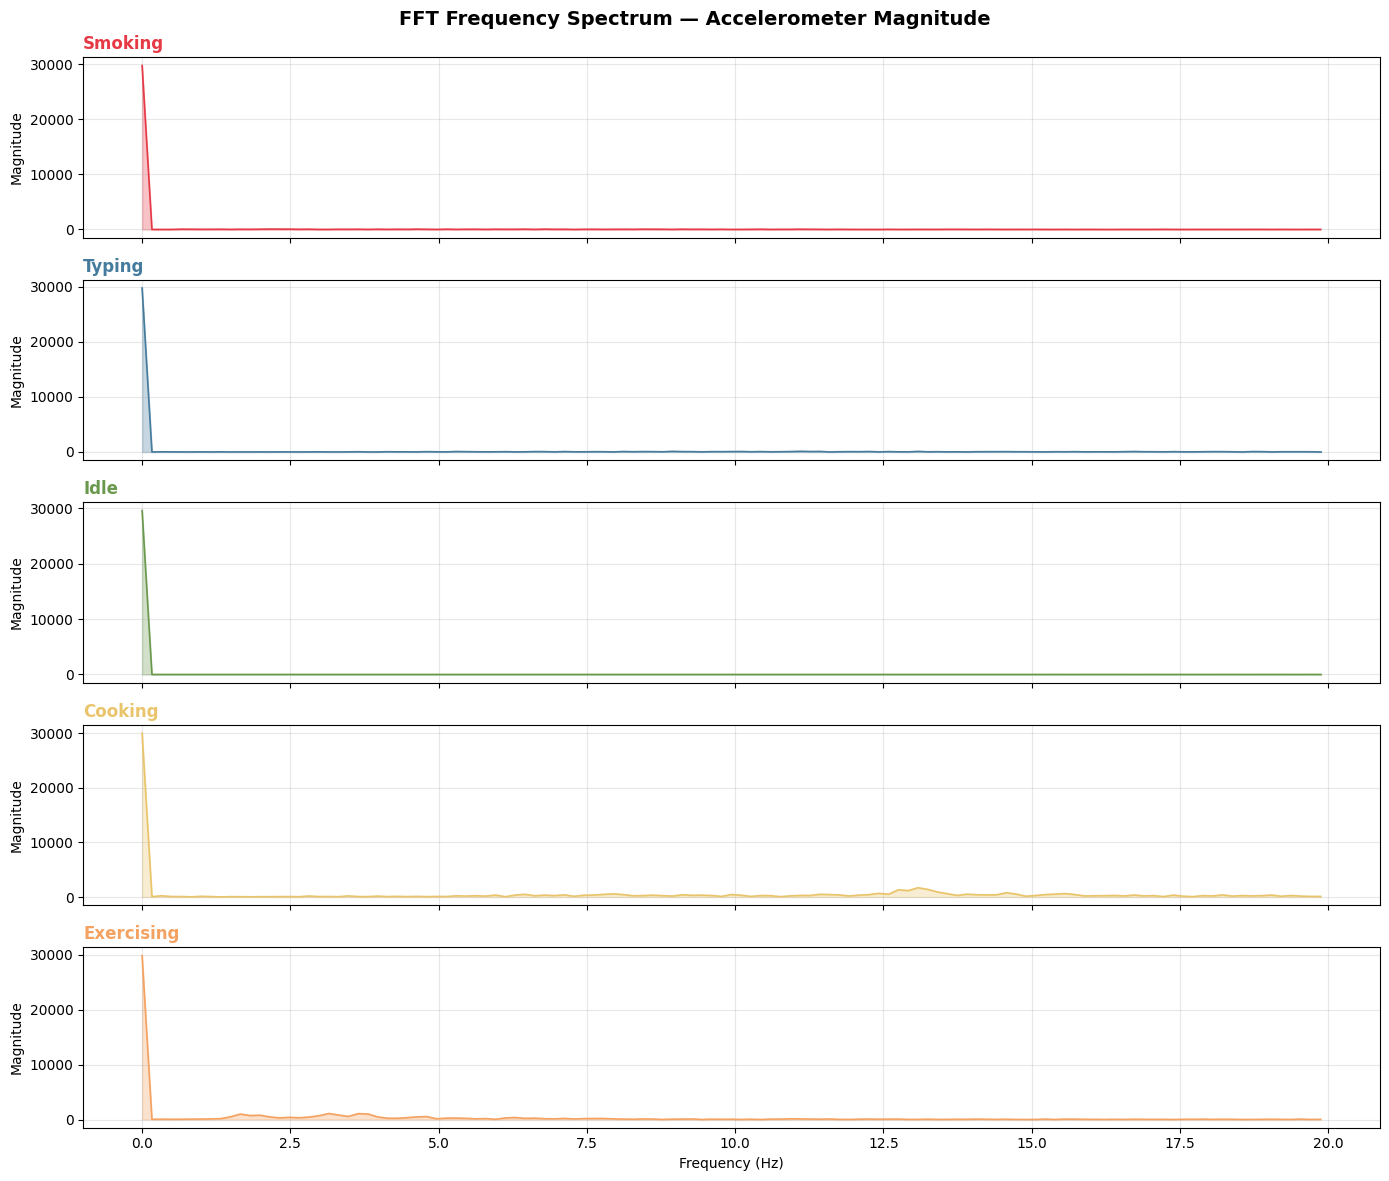

In [9]:
# ── FREQUENCY DOMAIN ──────────────────────────────────────────────────────────
# Shows dominant frequencies per activity
# Exercising will have a clear spike at ~1-2 Hz (step frequency)
# Typing will have energy spread across mid frequencies
# Idle will be flat / noise floor

SAMPLE_RATE = 500  # Hz — adjust if yours differs

fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 12), sharex=True)
fig.suptitle("FFT Frequency Spectrum — Accelerometer Magnitude", 
             fontsize=14, fontweight="bold")

for ax, activity in zip(axes, ACTIVITIES):
    sample = df[
        (df["activity"] == activity) &
        (df["session"]  == "session_01") &
        (df["subject"]  == "subject_1")
    ]["acc_mag"].values
    
    freqs    = rfftfreq(len(sample), d=1/SAMPLE_RATE)
    fft_vals = np.abs(rfft(sample))
    
    # Only plot up to 20 Hz — human motion lives here
    mask = freqs <= 20
    ax.plot(freqs[mask], fft_vals[mask], 
            color=PALETTE[activity], linewidth=1.2)
    ax.fill_between(freqs[mask], fft_vals[mask], 
                    alpha=0.3, color=PALETTE[activity])
    ax.set_title(activity.capitalize(), color=PALETTE[activity], 
                 fontweight="bold", loc="left")
    ax.set_ylabel("Magnitude")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig("../outputs/eda/04_fft_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

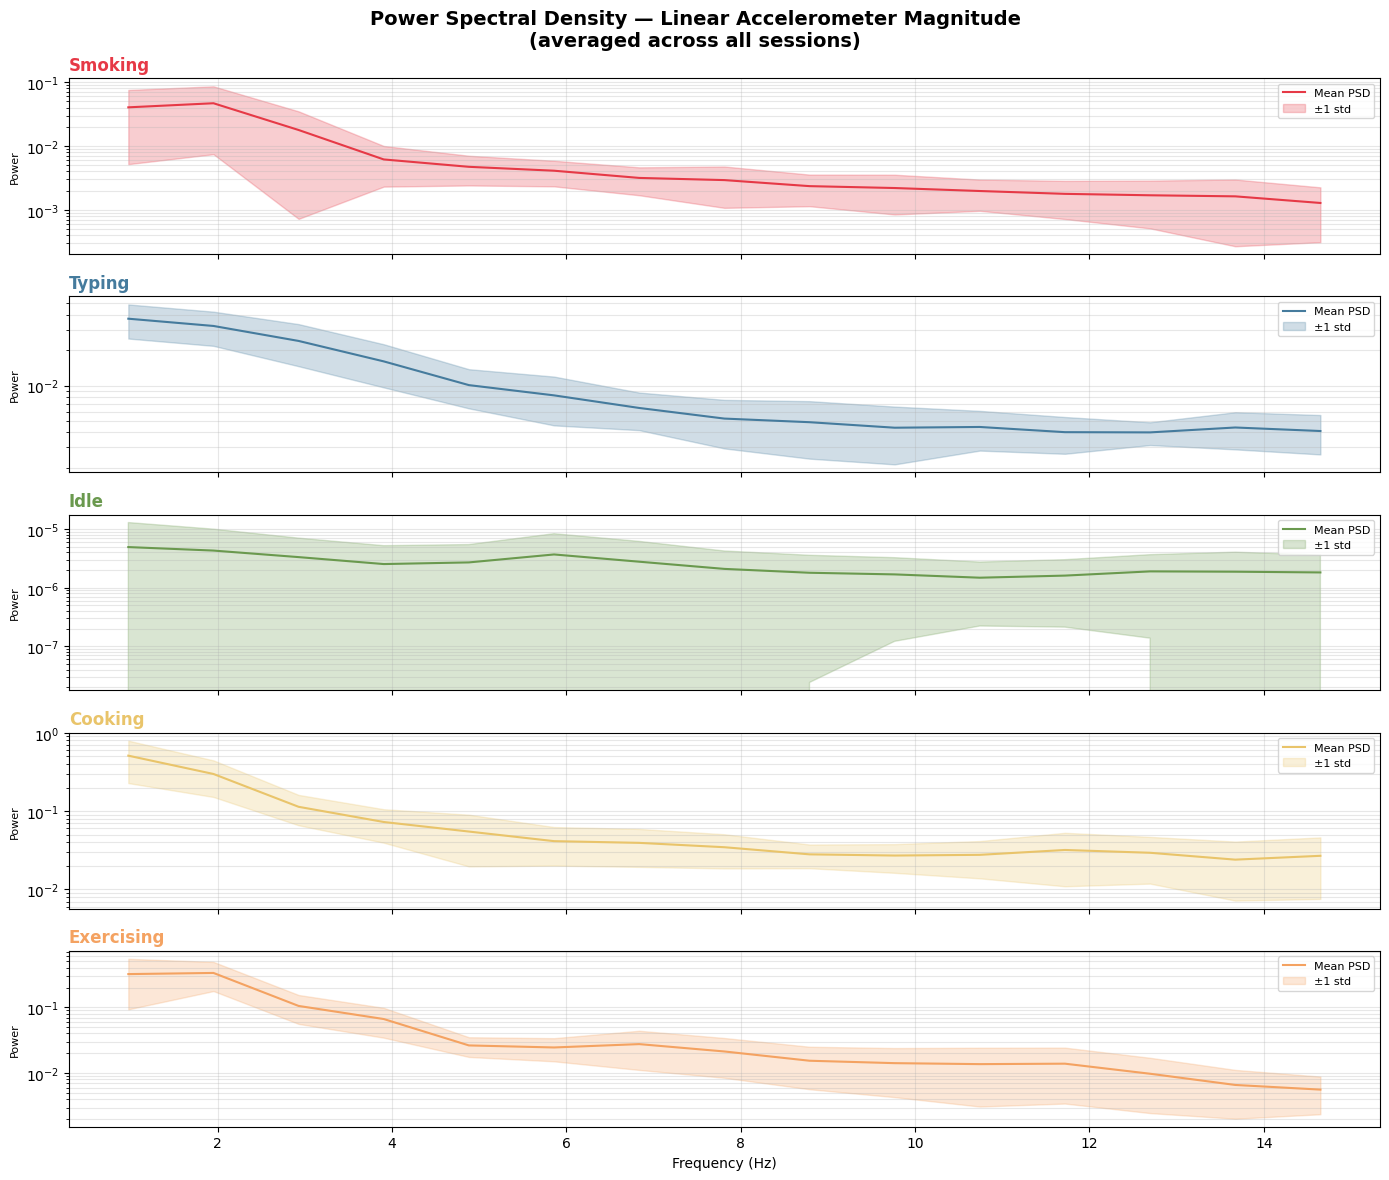

In [10]:
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch  # better than raw FFT for this

# ── MAKE SURE lin_mag EXISTS ──────────────────────────────────────────────────
df["lin_mag"] = np.sqrt(df["lin_x"]**2 + df["lin_y"]**2 + df["lin_z"]**2)

SAMPLE_RATE = 500

fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 12), sharex=True)
fig.suptitle("Power Spectral Density — Linear Accelerometer Magnitude\n(averaged across all sessions)",
             fontsize=14, fontweight="bold")

for ax, activity in zip(axes, ACTIVITIES):
    
    all_psd = []
    sessions = df[df["activity"] == activity][["subject","session"]].drop_duplicates()
    
    for _, row in sessions.iterrows():
        signal_vals = df[
            (df["activity"] == activity) &
            (df["subject"]  == row["subject"]) &
            (df["session"]  == row["session"])
        ]["lin_mag"].values
        
        # Remove DC offset — this is the key fix
        signal_vals = signal_vals - np.mean(signal_vals)
        
        # Welch method: far more stable than raw FFT
        # Breaks signal into overlapping chunks and averages their spectra
        freqs, psd = welch(signal_vals, fs=SAMPLE_RATE, 
                           nperseg=512,       # chunk size
                           noverlap=256)      # 50% overlap between chunks
        all_psd.append(psd)
    
    # Average PSD across all sessions for this activity
    mean_psd = np.mean(all_psd, axis=0)
    std_psd  = np.std(all_psd, axis=0)
    
    # Only show 0.5–15 Hz — human motion range
    mask = (freqs >= 0.5) & (freqs <= 15)
    
    ax.plot(freqs[mask], mean_psd[mask],
            color=PALETTE[activity], linewidth=1.5, label="Mean PSD")
    ax.fill_between(freqs[mask],
                    mean_psd[mask] - std_psd[mask],
                    mean_psd[mask] + std_psd[mask],
                    alpha=0.25, color=PALETTE[activity], label="±1 std")
    
    ax.set_title(activity.capitalize(), color=PALETTE[activity],
                 fontweight="bold", loc="left")
    ax.set_ylabel("Power", fontsize=8)
    ax.set_yscale("log")  # log scale reveals structure that's invisible linearly
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig("../outputs/eda/04_fft_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

In [1]:
# ── SENSOR CORRELATION ────────────────────────────────────────────────────────
# Shows which axes are correlated within each activity
# Different correlation patterns across activities = the model has something to learn

fig, axes = plt.subplots(1, len(ACTIVITIES), figsize=(20, 4))
fig.suptitle("Sensor Correlation Matrix Per Activity", 
             fontsize=14, fontweight="bold")

for ax, activity in zip(axes, ACTIVITIES):
    subset = df[df["activity"] == activity][SENSOR_COLS]
    corr   = subset.corr()
    
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=SENSOR_COLS, yticklabels=SENSOR_COLS,
                annot=False, cbar=False, linewidths=0.5)
    
    ax.set_title(activity.capitalize(), color=PALETTE[activity], fontweight="bold")
    ax.tick_params(labelsize=7, rotation=45)

plt.tight_layout()
plt.savefig("../outputs/eda/05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

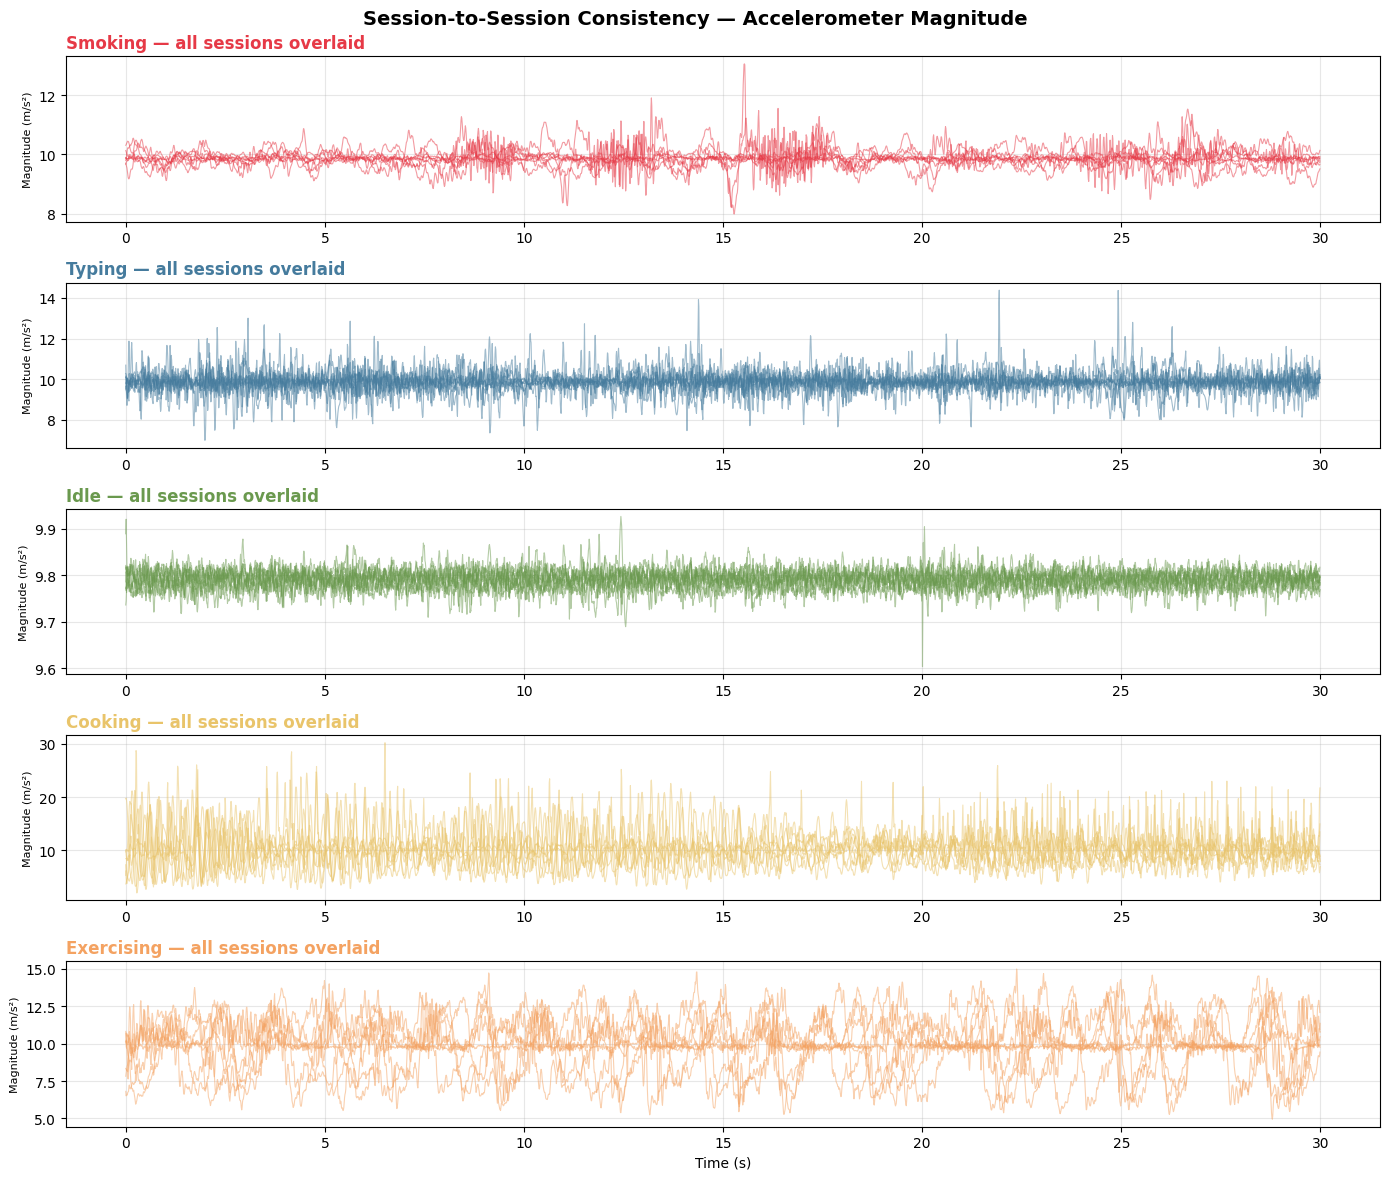

In [46]:
# ── INTRA-CLASS VARIANCE ──────────────────────────────────────────────────────
# Checks how consistent recordings are within the same activity
# High variance = the model will have a harder time learning that class
# Each line is one session — they should roughly overlap

fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 12), sharex=False)
fig.suptitle("Session-to-Session Consistency — Accelerometer Magnitude",
             fontsize=14, fontweight="bold")

for ax, activity in zip(axes, ACTIVITIES):
    sessions = df[(df["activity"] == activity) & 
                  (df["subject"] == "subject_1")]["session"].unique()
    
    for session in sessions:
        sample = df[
            (df["activity"] == activity) &
            (df["session"]  == session) &
            (df["subject"]  == "subject_1")
        ]
        ax.plot(sample["time"], sample["acc_mag"], 
                alpha=0.5, linewidth=0.8,
                color=PALETTE[activity],
                label=session)
    
    ax.set_title(f"{activity.capitalize()} — all sessions overlaid", 
                 color=PALETTE[activity], fontweight="bold", loc="left")
    ax.set_ylabel("Magnitude (m/s²)", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("../outputs/eda/06_session_variance.png", dpi=150, bbox_inches="tight")
plt.show()

# If sessions for one activity look wildly different from each other,
# that's a sign you need to be more consistent in how you perform it

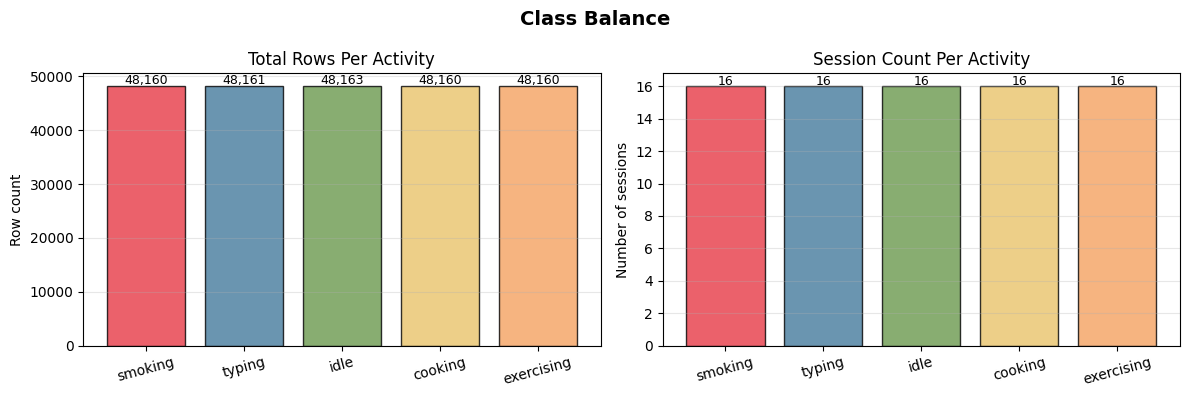

In [48]:
# ── CLASS BALANCE ─────────────────────────────────────────────────────────────
# Sanity check — all 5 classes should have roughly equal row counts
# Imbalance here = imbalance in your training data

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Balance", fontsize=14, fontweight="bold")

# By row count
counts = df.groupby("activity").size().reindex(ACTIVITIES)
axes[0].bar(counts.index, counts.values, 
            color=[PALETTE[a] for a in counts.index], alpha=0.8, edgecolor="black")
axes[0].set_title("Total Rows Per Activity")
axes[0].set_ylabel("Row count")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# By session count
session_counts = df.groupby(["activity","subject","session"]).ngroups
session_df     = df.groupby(["activity"]).apply(
    lambda x: x.groupby(["subject","session"]).ngroups
).reindex(ACTIVITIES)
axes[1].bar(session_df.index, session_df.values,
            color=[PALETTE[a] for a in session_df.index], alpha=0.8, edgecolor="black")
axes[1].set_title("Session Count Per Activity")
axes[1].set_ylabel("Number of sessions")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(session_df.values):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/eda/07_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

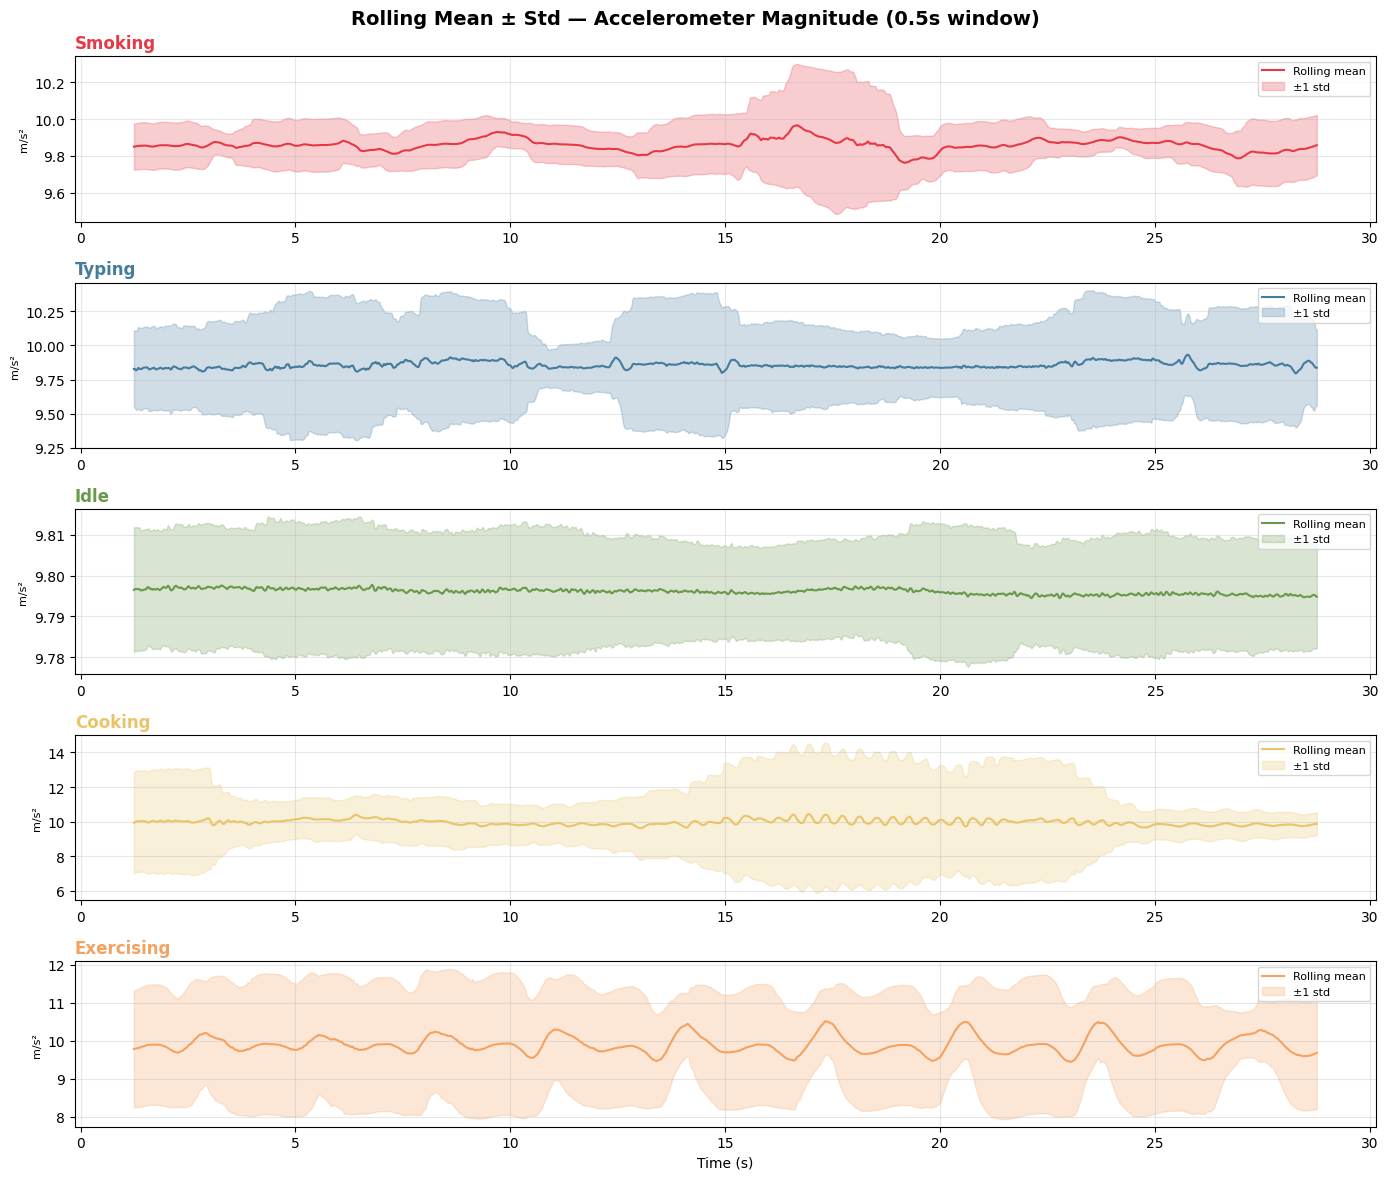

In [50]:
# ── ROLLING MEAN + STD ────────────────────────────────────────────────────────
# Shows local mean and variance over time
# Useful for seeing if activity changes mid-session (bad recording)
# or if there are clearly "active" and "rest" sub-periods within a clip

fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 12))
fig.suptitle("Rolling Mean ± Std — Accelerometer Magnitude (0.5s window)",
             fontsize=14, fontweight="bold")

WINDOW = 250  # ~0.5s at 500Hz

for ax, activity in zip(axes, ACTIVITIES):
    sample = df[
        (df["activity"] == activity) &
        (df["session"]  == "session_01") &
        (df["subject"]  == "subject_1")
    ].copy()
    
    sample["roll_mean"] = sample["acc_mag"].rolling(WINDOW, center=True).mean()
    sample["roll_std"]  = sample["acc_mag"].rolling(WINDOW, center=True).std()
    
    ax.plot(sample["time"], sample["roll_mean"], 
            color=PALETTE[activity], linewidth=1.5, label="Rolling mean")
    ax.fill_between(sample["time"],
                    sample["roll_mean"] - sample["roll_std"],
                    sample["roll_mean"] + sample["roll_std"],
                    alpha=0.25, color=PALETTE[activity], label="±1 std")
    
    ax.set_title(activity.capitalize(), color=PALETTE[activity], 
                 fontweight="bold", loc="left")
    ax.set_ylabel("m/s²", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("../outputs/eda/08_rolling_stats.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
def sliding_windows(df, window_size=2.0, step_size=1.0):
    windows = []
    
    sensor_cols = ["acc_x","acc_y","acc_z",
                   "gyr_x","gyr_y","gyr_z",
                   "lin_x","lin_y","lin_z"]
    
    for (subject, activity, session), group in df.groupby(["subject","activity","session"]):
        time = group["time"].values
        t = time[0]
        
        while t + window_size <= time[-1]:
            mask = (time >= t) & (time < t + window_size)
            window = group[mask]
            
            if len(window) > 20:  # skip near-empty windows
                windows.append({
                    "data": window[sensor_cols].values,
                    "subject": subject,
                    "activity": activity,
                    "session": session
                })
            t += step_size
    
    return windows

windows = sliding_windows(df)
print(f"Total windows: {len(windows)}")  # expect ~2,320

Total windows: 2240


In [54]:
def extract_features(window_data, cols):
    features = {}
    for i, col in enumerate(cols):
        vals = window_data[:, i]
        features[f"{col}_mean"]  = np.mean(vals)
        features[f"{col}_std"]   = np.std(vals)
        features[f"{col}_min"]   = np.min(vals)
        features[f"{col}_max"]   = np.max(vals)
        features[f"{col}_rms"]   = np.sqrt(np.mean(vals**2))
        features[f"{col}_range"] = np.max(vals) - np.min(vals)
        features[f"{col}_zcr"]   = ((vals[:-1] * vals[1:]) < 0).sum()
        
        fft_vals = np.abs(np.fft.rfft(vals))
        features[f"{col}_fft_max"]  = np.max(fft_vals)
        features[f"{col}_fft_dom"]  = np.argmax(fft_vals)
    return features

sensor_cols = ["acc_x","acc_y","acc_z","gyr_x","gyr_y","gyr_z","lin_x","lin_y","lin_z"]

feature_rows = []
for w in windows:
    feats = extract_features(w["data"], sensor_cols)
    feats["subject"]  = w["subject"]
    feats["activity"] = w["activity"]
    feats["session"]  = w["session"]
    feature_rows.append(feats)

feature_df = pd.DataFrame(feature_rows)
feature_df.to_parquet("../outputs/features/feature_matrix.parquet", index=False)

In [56]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = feature_df.drop(["subject","activity","session"], axis=1).values
y = LabelEncoder().fit_transform(feature_df["activity"].values)

train_mask = feature_df["subject"] == "subject_1"
X_train, X_test = X[train_mask],  X[~train_mask]
y_train, y_test = y[train_mask],  y[~train_mask]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [62]:
y_test.shape

(1120,)

In [63]:
y_test.shape

(1120,)

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM":           SVC(kernel="rbf"),
    "kNN":           KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: {score:.3f}")

Random Forest: 0.601
SVM: 0.733
kNN: 0.786


In [80]:
y_train

array([0, 0, 0, ..., 4, 4, 4], shape=(1120,))